# Colour and palettes in spatialdata-plot

This tutorial covers how `spatialdata-plot` decides what colours to draw, and the helpers it ships for building palettes. By the end you should be able to:

- Reason about where a colour comes from when you write `color=...`.
- Use `groups` to focus on a subset of categories without throwing the rest away.
- Build perceptually well-spaced and colourblind-safe palettes with `make_palette` and `make_palette_from_data`.

We use the synthetic `blobs` dataset throughout so the notebook stays small and reproducible.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import spatialdata as sd
import spatialdata_plot as sdp  # registers the .pl accessor; also aliased for sdp.pl.make_palette below

sdata = sd.datasets.blobs()
sdata

SpatialData object
├── Images
│     ├── 'blobs_image': DataArray[cyx] (3, 512, 512)
│     └── 'blobs_multiscale_image': DataTree[cyx] (3, 512, 512), (3, 256, 256), (3, 128, 128)
├── Labels
│     ├── 'blobs_labels': DataArray[yx] (512, 512)
│     └── 'blobs_multiscale_labels': DataTree[yx] (512, 512), (256, 256), (128, 128)
├── Points
│     └── 'blobs_points': DataFrame with shape: (<Delayed>, 4) (2D points)
├── Shapes
│     ├── 'blobs_circles': GeoDataFrame shape: (5, 2) (2D shapes)
│     ├── 'blobs_multipolygons': GeoDataFrame shape: (2, 1) (2D shapes)
│     └── 'blobs_polygons': GeoDataFrame shape: (5, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (26, 3)
with coordinate systems:
    ▸ 'global', with elements:
        blobs_image (Images), blobs_multiscale_image (Images), blobs_labels (Labels), blobs_multiscale_labels (Labels), blobs_points (Points), blobs_circles (Shapes), blobs_multipolygons (Shapes), blobs_polygons (Shapes)

We need a categorical column with a few levels to show off palettes. `blobs` ships with a 2-category `genes` column on the points, so we synthesise a 5-category `cell_type` annotation on the labels table and a `region_type` on `blobs_polygons` to exercise the column-on-element path.

In [2]:
rng = np.random.default_rng(0)

# Categorical on the table (annotates blobs_labels)
table = sdata.tables['table']
table.obs['cell_type'] = pd.Categorical(
    rng.choice(['A', 'B', 'C', 'D', 'E'], size=table.n_obs),
    categories=['A', 'B', 'C', 'D', 'E'],
)

# Categorical directly on a shapes GeoDataFrame
sdata.shapes['blobs_polygons']['region_type'] = pd.Categorical(
    ['stroma', 'tumour', 'stroma', 'immune', 'tumour'],
)

table.obs['cell_type'].value_counts().sort_index()

cell_type
A    5
B    4
C    4
D    6
E    7
Name: count, dtype: int64

## 1. Where does my colour come from?

When you pass `color=` to a `render_*` function, `spatialdata-plot` resolves it in a fixed order:

1. **Literal colour** — if the string parses as a colour (hex like `'#ff0000'`, a named matplotlib colour, or an RGB(A) tuple), it's used directly.
2. **Column name** — otherwise it's looked up on the element itself (the GeoDataFrame for shapes/points), then on the linked AnnData table's `obs` (or `var` for gene expression).
3. **Stored colours** — for a categorical column, if no `palette=` is given, the matching `adata.uns['<column>_colors']` entry is honoured (the AnnData convention scanpy writes).

Because step 1 wins, a few matplotlib shorthands that commonly collide with gene or column names are **deliberately rejected** so they fall through to the column lookup: greyscale strings (`'0'`, `'0.5'`, `'1'`), single-letter colours (`'r'`, `'g'`, `'b'`, …), the `Cn` cycle (`'C0'`, `'C1'`, …), and `tab:`/`xkcd:` prefixes. A column named `'red'`, on the other hand, is still parseable as a colour and would be misread — rename it before plotting.

The next three cells walk through each branch.

### Literal colour

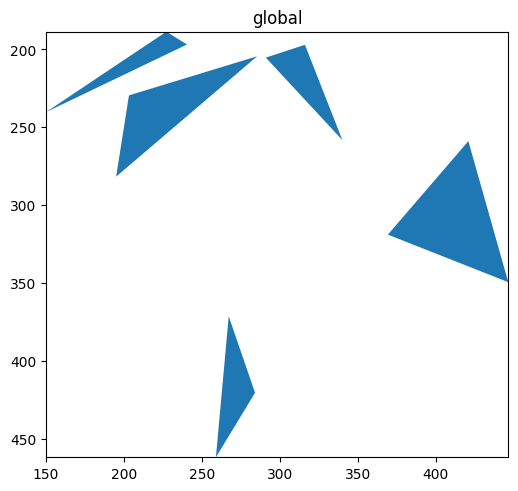

In [3]:
sdata.pl.render_shapes('blobs_polygons', color='#1f77b4').pl.show()

### Column on the element

`region_type` lives directly on the `blobs_polygons` GeoDataFrame. It is found there first, so no table lookup is needed.

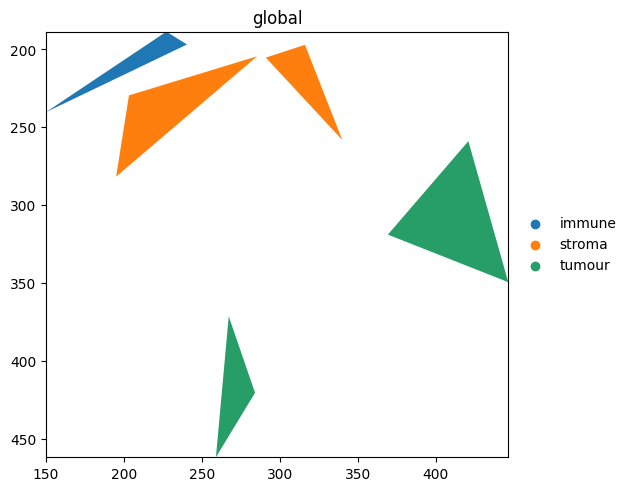

In [4]:
sdata.pl.render_shapes('blobs_polygons', color='region_type').pl.show()

### Stored colours in `.uns`

If you've already coloured a categorical column elsewhere (e.g. in scanpy), the matching `'<column>_colors'` entry in `.uns` is honoured automatically. Setting it explicitly:

rendered with: ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']


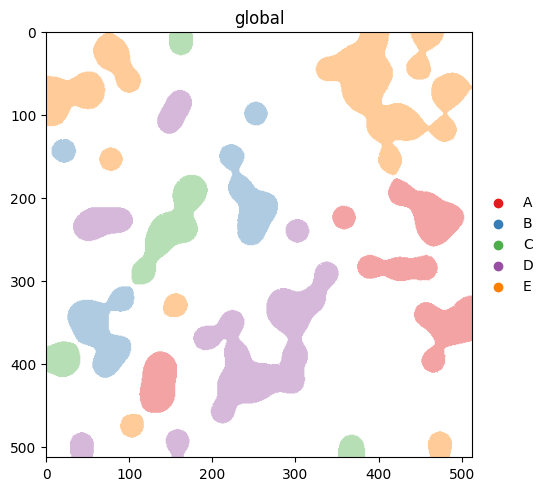

In [5]:
table.uns['cell_type_colors'] = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
sdata.pl.render_labels('blobs_labels', color='cell_type').pl.show()
print('rendered with:', table.uns['cell_type_colors'])

An explicit `palette=` argument overrides `.uns`. The precedence is: explicit `palette=` > `.uns['<col>_colors']` > scanpy defaults. Compare this output with the next section, where we clear `.uns['cell_type_colors']` and let the scanpy defaults take over.

## 2. Categorical vs continuous

`spatialdata-plot` infers whether a column is categorical or continuous from its dtype. Categorical columns use `palette=`; continuous columns use `cmap=`. We clear the `.uns['cell_type_colors']` we set above so this section actually exercises the scanpy fallback.

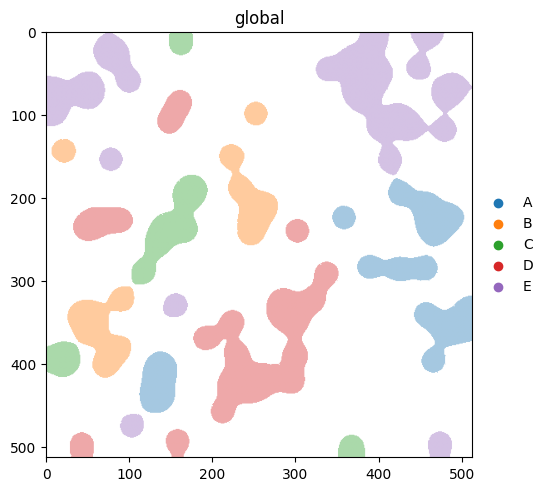

In [6]:
del table.uns['cell_type_colors']

(
    sdata.pl.render_labels('blobs_labels', color='cell_type')  # categorical -> palette
    .pl.show()
)

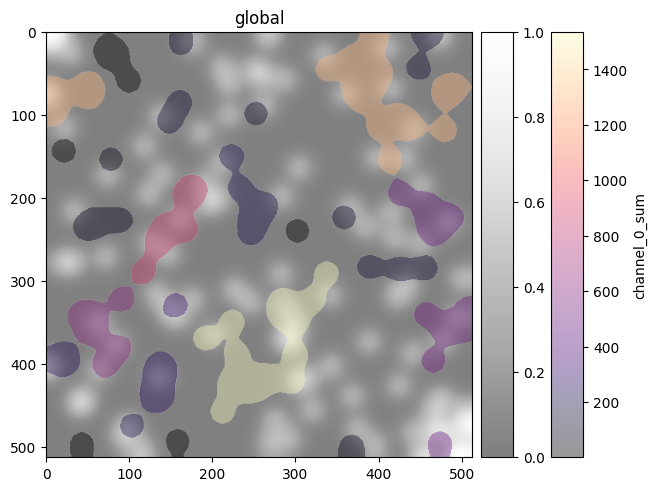

In [7]:
(
    sdata.pl.render_images('blobs_image', channel=0, cmap='Greys_r', alpha=0.5)
    .pl.render_labels('blobs_labels', color='channel_0_sum', cmap='magma')  # continuous -> cmap
    .pl.show()
)

## 3. Focusing on a subset with `groups`

`groups=` selects categories to highlight. As of v0.3.0, **non-matching elements are hidden by default**. If you'd rather see them in a neutral colour, pass `na_color`.

### Default: non-group elements hidden

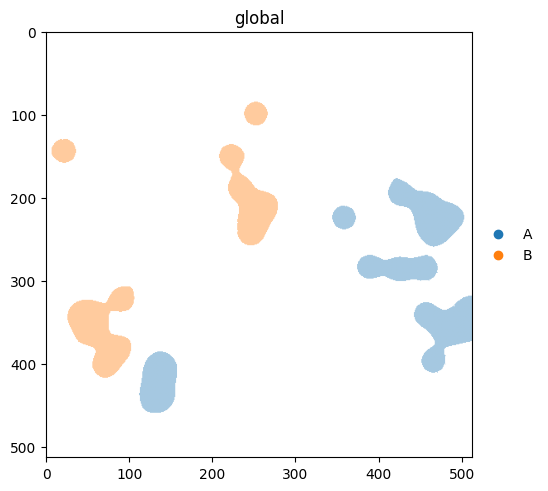

In [8]:
sdata.pl.render_labels('blobs_labels', color='cell_type', groups=['A', 'B']).pl.show()

### With `na_color`: non-group elements rendered in a neutral colour

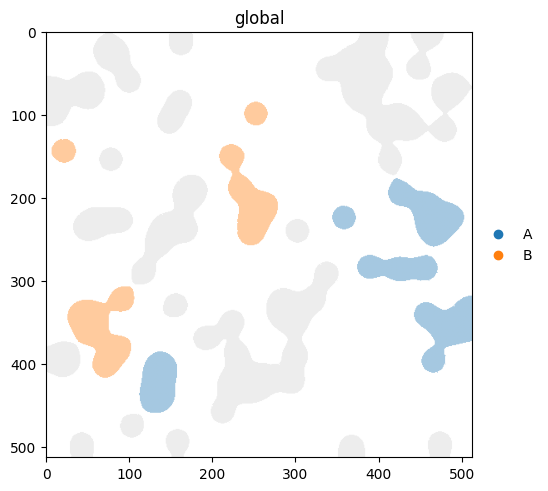

In [9]:
(
    sdata.pl.render_labels(
        'blobs_labels',
        color='cell_type',
        groups=['A', 'B'],
        na_color='lightgrey',
    )
    .pl.show()
)

> **v0.3.0 note.** Earlier versions rendered non-matching categories in the default NA colour by default. Now the default is to hide them, and you opt back into the old behaviour by passing `na_color`. Pass `na_color='lightgrey'` (or any colour) any time you want context, not just focus.

## 4. Building palettes with `make_palette`

`make_palette(n, palette=..., method=...)` returns a list of `n` hex colours. Two knobs:

- `palette` controls **which** colours are sampled. Accepts `None` (scanpy defaults), a list, a named palette like `'okabe_ito'`, or any matplotlib colormap name.
- `method` controls **how** they're ordered. `'default'` keeps source order; `'contrast'` reorders for maximum pairwise perceptual distance; `'colorblind'` reorders for the worst-case CVD type; `'protanopia'` / `'deuteranopia'` / `'tritanopia'` reorder for a specific CVD type.

A small helper to inspect a palette as a strip of swatches:

In [10]:
def show_palette(colors: list[str], title: str = '') -> None:
    fig, ax = plt.subplots(figsize=(len(colors) * 0.6, 0.8))
    for i, c in enumerate(colors):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=c))
    ax.set_xlim(0, len(colors))
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, loc='left')
    plt.show()

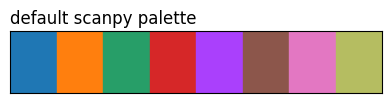

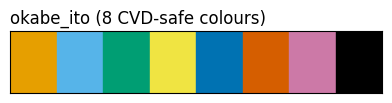

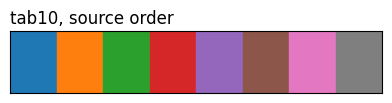

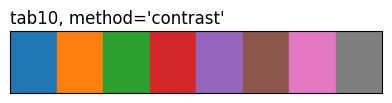

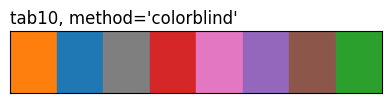

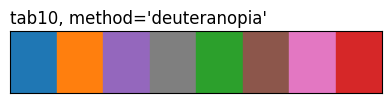

In [11]:
show_palette(sdp.pl.make_palette(8), 'default scanpy palette')
show_palette(sdp.pl.make_palette(8, palette='okabe_ito'), "okabe_ito (8 CVD-safe colours)")
show_palette(sdp.pl.make_palette(8, palette='tab10'), 'tab10, source order')
show_palette(sdp.pl.make_palette(8, palette='tab10', method='contrast'), "tab10, method='contrast'")
show_palette(sdp.pl.make_palette(8, palette='tab10', method='colorblind'), "tab10, method='colorblind'")
show_palette(sdp.pl.make_palette(8, palette='tab10', method='deuteranopia'), "tab10, method='deuteranopia'")

The three `tab10` rows highlight what `method` does: same eight source colours, different ordering. `'contrast'` and the CVD methods reorder by pairwise perceptual distance (under normal vision or a simulated deficiency), so the first few entries are spread further apart than they'd be in source order.

## 5. Palettes that already know your categories

`make_palette_from_data(sdata, element, color, ...)` returns a `{category: hex}` dictionary you can pass straight back into a render call. Useful when you want one palette to stay consistent across multiple plots, or when the category order matters.

In [12]:
palette = sdp.pl.make_palette_from_data(
    sdata,
    element='blobs_polygons',
    color='region_type',
    palette='tab10',
    method='contrast',
)
palette

{'immune': '#ff7f0e', 'stroma': '#2ca02c', 'tumour': '#1f77b4'}

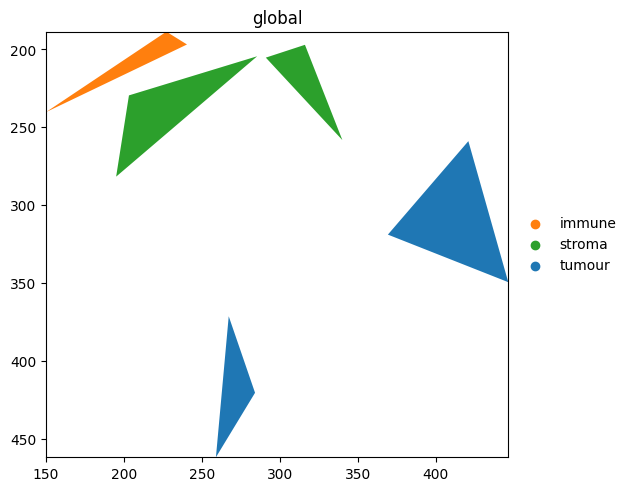

In [13]:
sdata.pl.render_shapes('blobs_polygons', color='region_type', palette=palette).pl.show()

Because `palette` is a dict, the colour for `'tumour'` is the same across every plot you reuse it in — handy for multi-panel figures.

> `make_palette_from_data` currently supports `shapes` and `points` elements. For labels, set `adata.uns['<col>_colors']` or pass `palette=[...]` directly to `render_labels`.

## 6. Which `render_*` accepts what

| Function | `palette` | `cmap` | `na_color` |
|---|---|---|---|
| `render_shapes` | dict / list / str | yes | yes |
| `render_points` | dict / list / str | yes | yes |
| `render_labels` | dict / list / str | yes | yes |
| `render_images` | — (channels only) | yes | — |

`render_images` colours pixels per channel, so `palette` and `na_color` don't apply. Pass a list of cmaps via `cmap=[...]` to colour individual channels.

## For reproducibility

In [14]:
# ruff: noqa: F401, F811, I001, E402
# fmt: off
import warnings
import dask
import spatialdata_plot

%load_ext watermark
# fmt: on

%watermark -v -m -p spatialdata,spatialdata_plot,matplotlib,numpy,pandas

Python implementation: CPython
Python version       : 3.13.7
IPython version      : 9.13.0

spatialdata     : 0.7.3
spatialdata_plot: 0.3.4
matplotlib      : 3.10.9
numpy           : 2.4.4
pandas          : 2.3.3

Compiler    : Clang 15.0.0 (clang-1500.1.0.2.5)
OS          : Darwin
Release     : 25.2.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit

